<a href="https://colab.research.google.com/github/ShubhamVermaDev9/ML-projects/blob/main/SeoulBikeData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
import copy
import seaborn as sns
import tensorflow as tf
from sklearn.linear_model import LinearRegression

In [3]:
dataset_cols = ["bike_count", "hour", "temp", "humidity", "wind", "visibility", "dew_pt_temp", "radiation", "rain", "snow", "functional"]
df = pd.read_csv("SeoulBikeData.csv", encoding='latin1').drop(["Date", "Holiday", "Seasons"], axis=1)

In [4]:
df.columns = dataset_cols
df["functional"] = (df["functional"] == "Yes").astype(int)
df = df[df["hour"] == 12]
df = df.drop(["hour"], axis=1)

In [5]:
df.head()

,bike_count,temp,humidity,wind,visibility,dew_pt_temp,radiation,rain,snow,functional
12,449,1.7,23,1.4,2000,-17.2,1.11,0.0,0.0,1
36,479,4.3,41,1.3,1666,-7.8,1.09,0.0,0.0,1
60,333,5.8,85,1.7,349,3.4,0.43,0.0,0.0,1
84,393,-0.3,38,4.8,1823,-12.9,1.11,0.0,0.0,1
108,321,-2.3,25,0.0,1962,-19.7,0.00,0.0,0.0,1


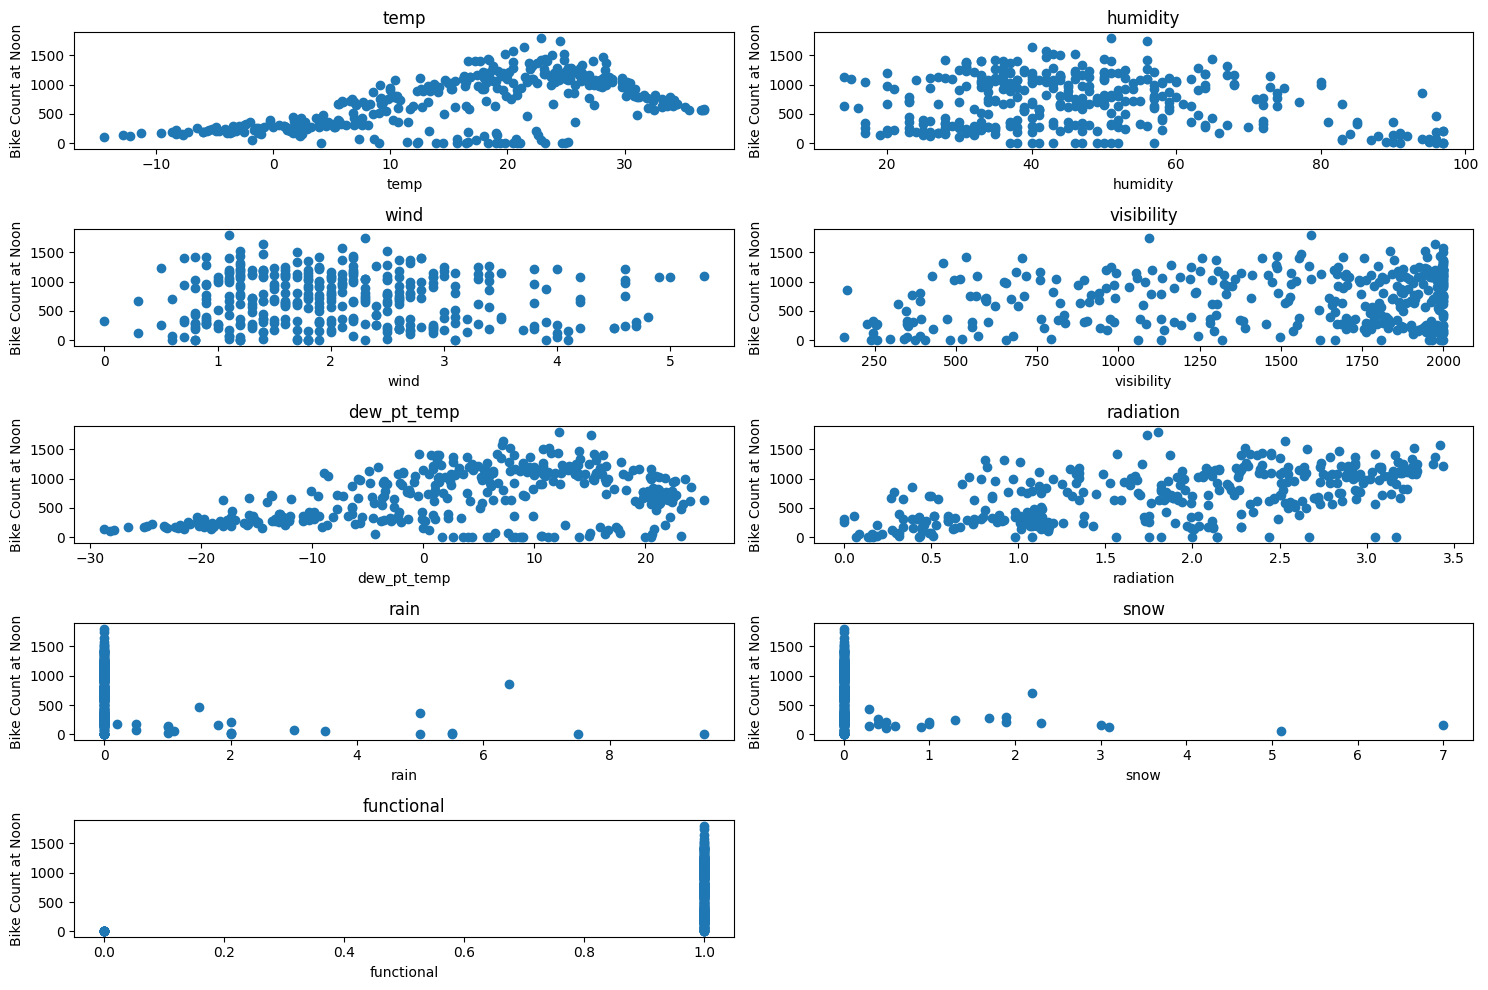

In [7]:
import matplotlib.pyplot as plt

cols = df.columns[1:]
n = len(cols)

plt.figure(figsize=(15, 10))

for i, label in enumerate(cols, 1):
    plt.subplot((n + 1) // 2, 2, i)
    plt.scatter(df[label], df["bike_count"])
    plt.title(label)
    plt.xlabel(label)
    plt.ylabel("Bike Count at Noon")

plt.tight_layout()
plt.show()

In [8]:
df = df.drop(["wind", "visibility", "functional"], axis=1)

In [9]:
df.head()

,bike_count,temp,humidity,dew_pt_temp,radiation,rain,snow
12,449,1.7,23,-17.2,1.11,0.0,0.0
36,479,4.3,41,-7.8,1.09,0.0,0.0
60,333,5.8,85,3.4,0.43,0.0,0.0
84,393,-0.3,38,-12.9,1.11,0.0,0.0
108,321,-2.3,25,-19.7,0.00,0.0,0.0


In [10]:
train, val, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [11]:
def get_xy(dataframe, y_label, x_labels=None):
  dataframe = copy.deepcopy(dataframe)
  if x_labels is None:
    X = dataframe[[c for c in dataframe.columns if c!=y_label]].values
  else:
    if len(x_labels) == 1:
      X = dataframe[x_labels[0]].values.reshape(-1, 1)
    else:
      X = dataframe[x_labels].values

  y = dataframe[y_label].values.reshape(-1, 1)
  data = np.hstack((X, y))

  return data, X, y

In [12]:
_, X_train_temp, y_train_temp = get_xy(train, "bike_count", x_labels=["temp"])
_, X_val_temp, y_val_temp = get_xy(val, "bike_count", x_labels=["temp"])
_, X_test_temp, y_test_temp = get_xy(test, "bike_count", x_labels=["temp"])

# **LinearRegression**

In [13]:
temp_reg = LinearRegression()
temp_reg.fit(X_train_temp, y_train_temp)

LinearRegression()

In [24]:
from sklearn.metrics import r2_score
y_pred=temp_reg.predict(X_test_temp)
print(f"R-squared on test set: {r2_score(y_test_temp, y_pred):.2f}")

R-squared on test set: 0.37


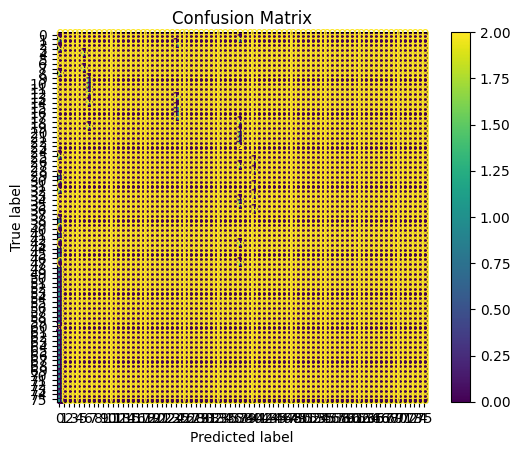

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test_temp, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

# **KNN**

In [15]:
from sklearn.neighbors import KNeighborsClassifier
knn_madel=KNeighborsClassifier(n_neighbors=5)
knn_madel.fit(X_train_temp,y_train_temp)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier()

In [20]:
from sklearn.metrics import classification_report
y_pred=knn_madel.predict(X_test_temp)
print(classification_report(y_test_temp,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
          10       0.00      0.00      0.00       2.0
          11       0.00      0.00      0.00       0.0
          25       0.00      0.00      0.00       0.0
          59       0.00      0.00      0.00       0.0
          62       0.00      0.00      0.00       0.0
          63       0.00      0.00      0.00       0.0
          71       0.00      0.00      0.00       0.0
          75       0.00      0.00      0.00       0.0
         119       0.00      0.00      0.00       1.0
         137       0.00      0.00      0.00       1.0
         145       0.00      0.00      0.00       1.0
         157       0.00      0.00      0.00       0.0
         167       0.00      0.00      0.00       0.0
         174       0.00      0.00      0.00       0.0
         178       0.00      0.00      0.00       1.0
         180       0.00      0.00      0.00       1.0
         188       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

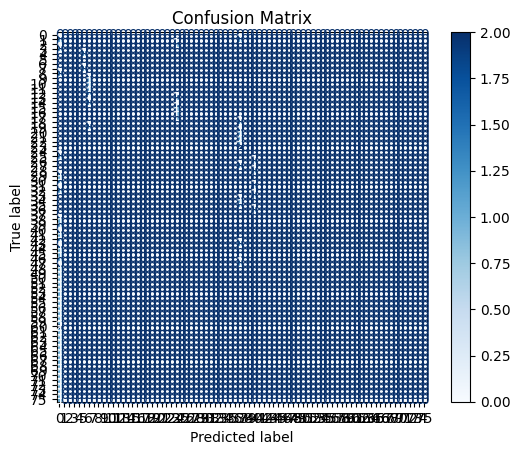

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_temp, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

# **SVM**

In [25]:
from sklearn.svm import SVC
svm_model=SVC()
svm_model.fit(X_train_temp,y_train_temp)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC()

In [26]:
y_pred=svm_model.predict(X_test_temp)
print(classification_report(y_test_temp,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
          10       0.00      0.00      0.00       2.0
         119       0.00      0.00      0.00       1.0
         137       0.00      0.00      0.00       1.0
         145       0.00      0.00      0.00       1.0
         174       0.00      0.00      0.00       0.0
         178       0.00      0.00      0.00       1.0
         180       0.00      0.00      0.00       1.0
         188       0.00      0.00      0.00       1.0
         189       0.00      0.00      0.00       1.0
         191       0.00      0.00      0.00       1.0
         217       0.00      0.00      0.00       1.0
         225       0.00      0.00      0.00       1.0
         240       0.00      0.00      0.00       1.0
         248       0.00      0.00      0.00       1.0
         263       0.00      0.00      0.00       1.0
         267       0.00      0.00      0.00       1.0
         278       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

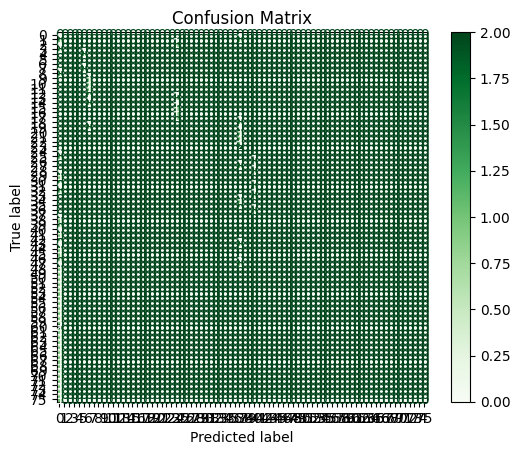

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_temp, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Greens')

plt.title("Confusion Matrix")
plt.show()

# **DecisionTree**

In [27]:
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier()
dt_model.fit(X_train_temp,y_train_temp)

DecisionTreeClassifier()

In [28]:
y_pred=dt_model.predict(X_test_temp)
print(classification_report(y_test_temp,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
          10       0.00      0.00      0.00       2.0
          25       0.00      0.00      0.00       0.0
          63       0.00      0.00      0.00       0.0
         119       0.00      0.00      0.00       1.0
         137       0.00      0.00      0.00       1.0
         145       0.00      0.00      0.00       1.0
         157       0.00      0.00      0.00       0.0
         167       0.00      0.00      0.00       0.0
         178       0.00      0.00      0.00       1.0
         180       0.00      0.00      0.00       1.0
         183       0.00      0.00      0.00       0.0
         187       0.00      0.00      0.00       0.0
         188       0.00      0.00      0.00       1.0
         189       0.00      0.00      0.00       1.0
         191       0.00      0.00      0.00       1.0
         217       0.00      0.00      0.00       1.0
         225       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

# **RandomForest**

In [29]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier()
rf_model.fit(X_train_temp,y_train_temp)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier()

In [30]:
y_pred=rf_model.predict(X_test_temp)
print(classification_report(y_test_temp,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
          10       0.00      0.00      0.00       2.0
          63       0.00      0.00      0.00       0.0
          71       0.00      0.00      0.00       0.0
         119       0.00      0.00      0.00       1.0
         137       0.00      0.00      0.00       1.0
         145       0.00      0.00      0.00       1.0
         157       0.00      0.00      0.00       0.0
         167       0.00      0.00      0.00       0.0
         178       0.00      0.00      0.00       1.0
         180       0.00      0.00      0.00       1.0
         183       0.00      0.00      0.00       0.0
         187       0.00      0.00      0.00       0.0
         188       0.00      0.00      0.00       1.0
         189       0.00      0.00      0.00       1.0
         191       0.00      0.00      0.00       1.0
         217       0.00      0.00      0.00       1.0
         225       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [32]:
from sklearn.naive_bayes import GaussianNB
nb_model=GaussianNB()
nb_model.fit(X_train_temp,y_train_temp)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GaussianNB()

In [33]:
y_pred=nb_model.predict(X_test_temp)
print(classification_report(y_test_temp,y_pred))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
          10       0.00      0.00      0.00       2.0
          25       0.00      0.00      0.00       0.0
         119       0.00      0.00      0.00       1.0
         137       0.00      0.00      0.00       1.0
         145       0.00      0.00      0.00       1.0
         167       0.00      0.00      0.00       0.0
         178       0.00      0.00      0.00       1.0
         180       0.00      0.00      0.00       1.0
         188       0.00      0.00      0.00       1.0
         189       0.00      0.00      0.00       1.0
         191       0.00      0.00      0.00       1.0
         217       0.00      0.00      0.00       1.0
         225       0.00      0.00      0.00       1.0
         240       0.00      0.00      0.00       1.0
         248       0.00      0.00      0.00       1.0
         263       0.00      0.00      0.00       1.0
         267       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [34]:
from sklearn.linear_model import LogisticRegression
lr_model=LogisticRegression()
lr_model.fit(X_train_temp,y_train_temp)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [35]:
y_pred=lr_model.predict(X_test_temp)
print(classification_report(y_test_temp,y_pred))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
          10       0.00      0.00      0.00       2.0
         119       0.00      0.00      0.00       1.0
         137       0.00      0.00      0.00       1.0
         145       0.00      0.00      0.00       1.0
         157       0.00      0.00      0.00       0.0
         174       0.00      0.00      0.00       0.0
         178       0.00      0.00      0.00       1.0
         180       0.00      0.00      0.00       1.0
         188       0.00      0.00      0.00       1.0
         189       0.00      0.00      0.00       1.0
         191       0.00      0.00      0.00       1.0
         217       0.00      0.00      0.00       1.0
         225       0.00      0.00      0.00       1.0
         240       0.00      0.00      0.00       1.0
         248       0.00      0.00      0.00       1.0
         263       0.00      0.00      0.00       1.0
         267       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

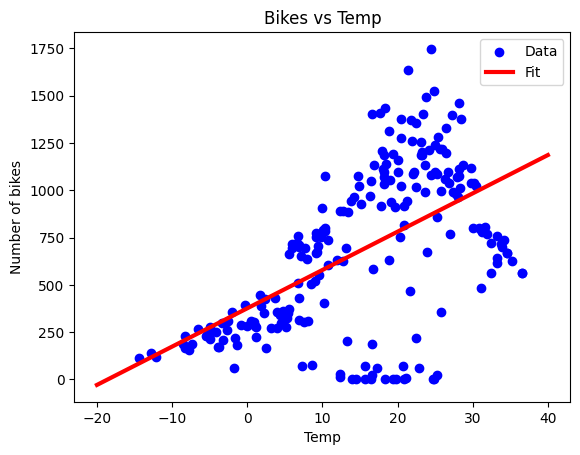

In [42]:
plt.scatter(X_train_temp, y_train_temp, label="Data", color="blue")
x = tf.linspace(-20, 40, 100)
plt.plot(x, temp_reg.predict(np.array(x).reshape(-1, 1)), label="Fit", color="red", linewidth=3)
plt.legend()
plt.title("Bikes vs Temp")
plt.ylabel("Number of bikes")
plt.xlabel("Temp")
plt.show()

# Multiple Linear **Regression**

In [43]:
train, val, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])
_, X_train_all, y_train_all = get_xy(train, "bike_count", x_labels=df.columns[1:])
_, X_val_all, y_val_all = get_xy(val, "bike_count", x_labels=df.columns[1:])
_, X_test_all, y_test_all = get_xy(test, "bike_count", x_labels=df.columns[1:])

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [44]:
all_reg = LinearRegression()
all_reg.fit(X_train_all, y_train_all)

LinearRegression()

In [45]:
all_reg.score(X_test_all, y_test_all)

0.4143929466680578

# Regression with Neural **Net**

In [46]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.xlabel('Epoch')
  plt.ylabel('MSE')
  plt.legend()
  plt.grid(True)
  plt.show()

In [47]:
temp_normalizer = tf.keras.layers.Normalization(input_shape=(1,), axis=None)
temp_normalizer.adapt(X_train_temp.reshape(-1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [48]:
temp_nn_model = tf.keras.Sequential([
    temp_normalizer,
    tf.keras.layers.Dense(1)
])

In [49]:
temp_nn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss='mean_squared_error')

In [50]:
history = temp_nn_model.fit(
    X_train_temp.reshape(-1), y_train_temp,
    verbose=0,
    epochs=1000,
    validation_data=(X_val_temp, y_val_temp)
)

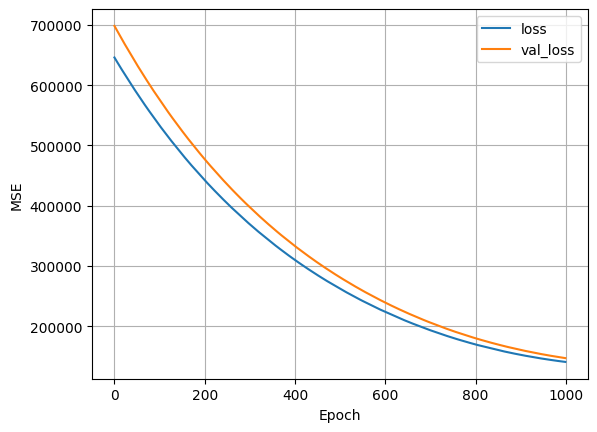

In [51]:
plot_loss(history)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


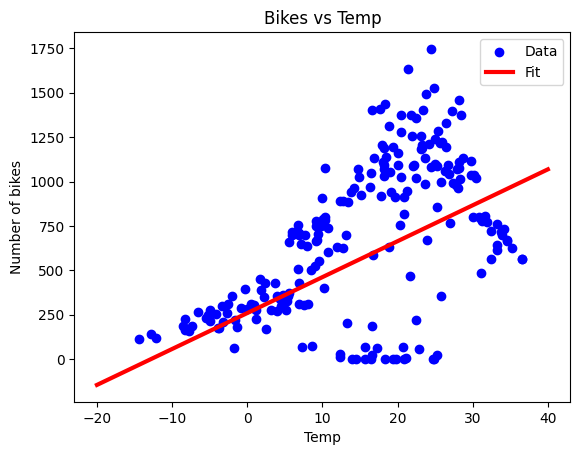

In [52]:
plt.scatter(X_train_temp, y_train_temp, label="Data", color="blue")
x = tf.linspace(-20, 40, 100)
plt.plot(x, temp_nn_model.predict(np.array(x).reshape(-1, 1)), label="Fit", color="red", linewidth=3)
plt.legend()
plt.title("Bikes vs Temp")
plt.ylabel("Number of bikes")
plt.xlabel("Temp")
plt.show()